# LSTM

Sequence-based pitch prediction RNN

## Exports and Loading Data

In [29]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')
 
# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
 
print("TensorFlow version:", tf.__version__)

print("\nLoading LSTM data...")
X_train = np.load('../../feature-engineering/X_train_lstm.npy')
X_test = np.load('../../feature-engineering/X_test_lstm.npy')
y_train = np.load('../../feature-engineering/y_train_lstm.npy')
y_test = np.load('../../feature-engineering/y_test_lstm.npy')
 
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
 
# Load encoder and feature names
with open('../../feature-engineering/pitch_type_encoder.pkl', 'rb') as f:
    pitch_encoder = pickle.load(f)
 
with open('../../feature-engineering/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)
 
n_features = X_train.shape[1]
n_classes = len(pitch_encoder.classes_)
 
print(f"\n{n_features} features, {n_classes} pitch types")

TensorFlow version: 2.20.0

Loading LSTM data...
X_train shape: (403984, 26)
X_test shape: (98161, 26)
y_train shape: (403984,)
y_test shape: (98161,)

26 features, 17 pitch types


## Baseline Accuracy

In [30]:
# Most common pitch in training set
unique, counts = np.unique(y_train, return_counts=True)
most_common_idx = unique[np.argmax(counts)]
baseline_accuracy = np.max(counts) / len(y_train)
 
print(f"\nMost common pitch: {pitch_encoder.classes_[most_common_idx]}")
print(f"Baseline accuracy (test): {baseline_accuracy:.1%}")
print(f"\nTARGET: Beat {baseline_accuracy:.1%} accuracy")


Most common pitch: FF
Baseline accuracy (test): 29.9%

TARGET: Beat 29.9% accuracy


## Building LSTM

In [31]:
model = models.Sequential([
    # Input layer
    layers.Input(shape=(n_features,)),
    
    # Dense layers (act as feature processing before sequence modeling)
    # We're treating each pitch as a feature vector
    # For true sequence modeling, we'd need to reshape as (seq_length, features)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer
    layers.Dense(n_classes, activation='softmax'),
])
 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 
print("\nModel architecture:")
model.summary()


Model architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 17)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,353 (56.07 KB)

 Trainable params: 14,353 (56.07 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [32]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
 
print("Training (this may take 1-2 minutes)...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=2048,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
 
print("\nTraining complete!")

Training (this may take 1-2 minutes)...
Epoch 1/30


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2669 - loss: 2.4445 - val_accuracy: 0.3644 - val_loss: 1.6670
Epoch 2/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3222 - loss: 1.7925 - val_accuracy: 0.3693 - val_loss: 1.5827
Epoch 3/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3376 - loss: 1.6932 - val_accuracy: 0.3744 - val_loss: 1.5402
Epoch 4/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3461 - loss: 1.6434 - val_accuracy: 0.3707 - val_loss: 1.5181
Epoch 5/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3519 - loss: 1.6080 - val_accuracy: 0.3752 - val_loss: 1.4936
Epoch 6/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3554 - loss: 1.5840 - val_accuracy: 0.3760 - val_loss: 1.4789
Epoch 7/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3587 - loss: 1.5651 - val_accuracy: 0.3769 - val_loss: 1.4658
Epoch 8/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3605 - loss: 1.5500 - val_accuracy: 0.3791 - val_

## Evaluation

In [33]:
# Predictions
y_pred_train = model.predict(X_train, verbose=0).argmax(axis=1)
y_pred_test = model.predict(X_test, verbose=0).argmax(axis=1)
 
# Accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
 
print(f"\nAccuracy:")
print(f"  Train: {train_accuracy:.3f} ({train_accuracy:.1%})")
print(f"  Test:  {test_accuracy:.3f} ({test_accuracy:.1%})")
print(f"  Baseline: {baseline_accuracy:.1%}")
print(f"  Improvement over baseline: +{(test_accuracy - baseline_accuracy):.1%}")
 
# Per-pitch accuracy
print(f"\nPer-pitch type accuracy (test set):")
pitch_types = pitch_encoder.classes_
for i, pitch in enumerate(pitch_types):
    mask = y_test == i
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_test[mask])
        count = mask.sum()
        print(f"  {pitch:3s}: {acc:.1%} ({count:6d} pitches)")


Accuracy:
  Train: 0.412 (41.2%)
  Test:  0.410 (41.0%)
  Baseline: 29.9%
  Improvement over baseline: +11.1%

Per-pitch type accuracy (test set):
  CH : 10.0% ( 12851 pitches)
  CS : 0.0% (     4 pitches)
  CU : 1.9% (  4495 pitches)
  EP : 100.0% (    75 pitches)
  FA : 0.0% (    13 pitches)
  FC : 14.1% (  7131 pitches)
  FF : 79.2% ( 29992 pitches)
  FS : 12.7% (  2600 pitches)
  KC : 9.8% (  3141 pitches)
  PO : 0.0% (     4 pitches)
  SI : 55.1% ( 16112 pitches)
  SL : 11.5% ( 13460 pitches)
  ST : 36.9% (  8106 pitches)
  SV : 0.0% (   176 pitches)
  UN : 0.0% (     1 pitches)


## Confusion Matrix


Most common confusions (predicted != actual):
  Actual CH -> Predicted FF:  9230 times ( 71.8%)
  Actual PO -> Predicted FF:  8092 times (202300.0%)
  Actual KN -> Predicted FF:  4237 times (  0.0%)
  Actual FC -> Predicted FF:  3668 times ( 51.4%)
  Actual PO -> Predicted KN:  3114 times (77850.0%)
  Actual SI -> Predicted FF:  3046 times ( 18.9%)
  Actual CU -> Predicted FF:  2910 times ( 64.7%)
  Actual FF -> Predicted KN:  2562 times (  8.5%)
  Actual FS -> Predicted FF:  2271 times ( 87.3%)
  Actual FO -> Predicted FF:  1885 times (  0.0%)
  Actual FF -> Predicted SI:  1649 times (  5.5%)
  Actual SI -> Predicted KN:  1602 times (  9.9%)
  Actual FC -> Predicted KN:  1574 times ( 22.1%)
  Actual CH -> Predicted KN:  1432 times ( 11.1%)
  Actual KN -> Predicted SI:  1329 times (  0.0%)

Generating confusion matrix heatmap...
Saved lstm_confusion_matrix.png


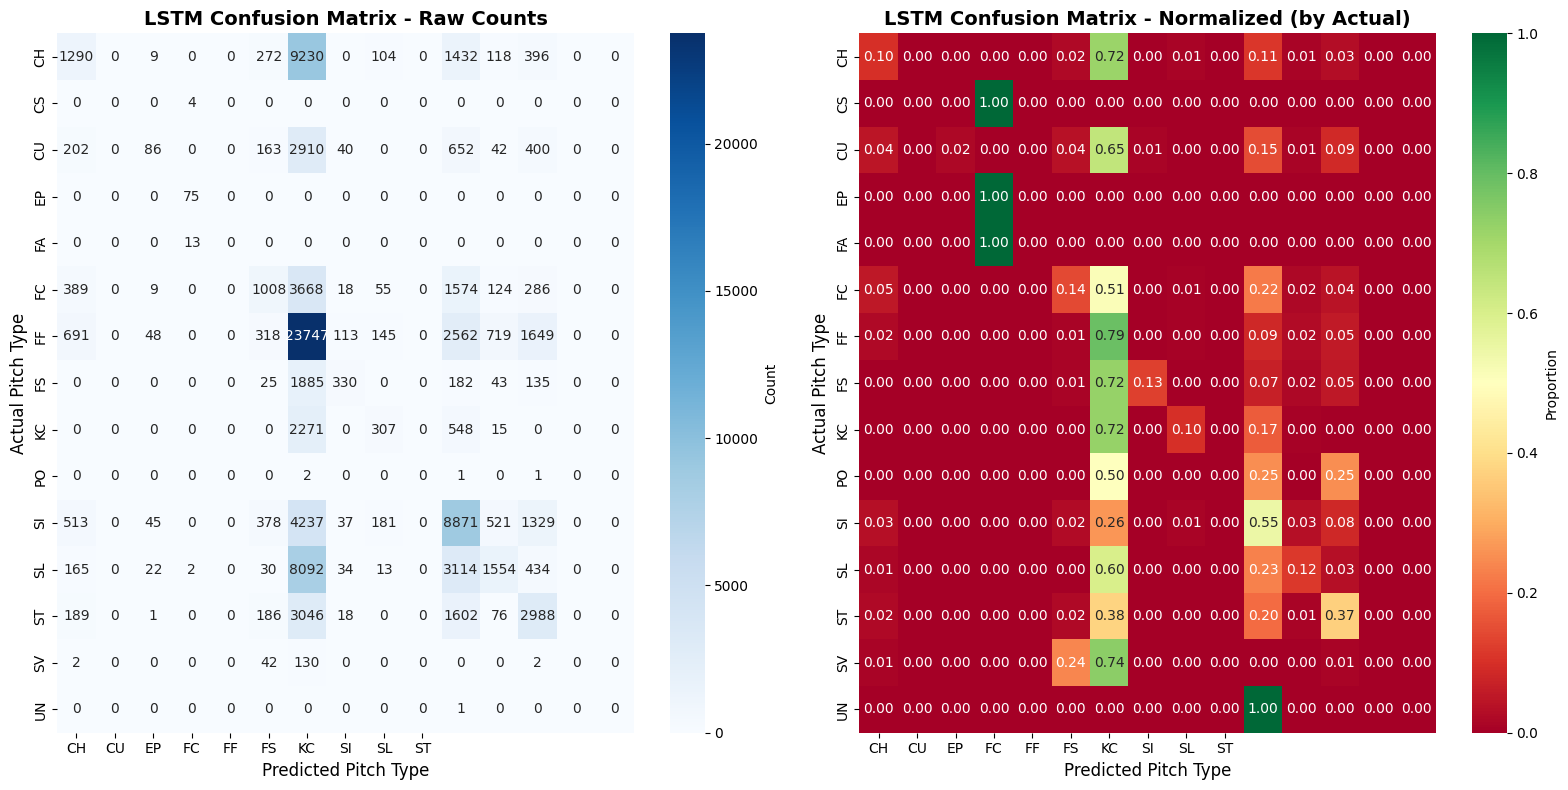

In [34]:
cm = confusion_matrix(y_test, y_pred_test)
 
print("\nMost common confusions (predicted != actual):")
confusions = []
 
# Handle case where test set doesn't have all pitch types
# cm shape is (n_actual_classes, n_predicted_classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j:
            count = cm[i, j]
            if count > 0:
                # Get pitch names - handle missing classes
                actual_pitch = pitch_types[i] if i < len(pitch_types) else f"Unknown_{i}"
                pred_pitch = pitch_types[j] if j < len(pitch_types) else f"Unknown_{j}"
                confusions.append((actual_pitch, pred_pitch, count))
 
# Sort by frequency
confusions.sort(key=lambda x: x[2], reverse=True)
for actual, predicted, count in confusions[:15]:
    # Calculate percentage safely
    actual_idx = np.where(pitch_types == actual)[0]
    if len(actual_idx) > 0:
        total_actual = (y_test == actual_idx[0]).sum()
        pct = count / total_actual * 100 if total_actual > 0 else 0
        print(f"  Actual {actual} -> Predicted {predicted}: {count:5d} times ({pct:5.1f}%)")

# Confusion Matrix Heatmap
print("\nGenerating confusion matrix heatmap...")
 
# Create a DataFrame for the confusion matrix with pitch type labels
# Normalize by row (actual pitch type) to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
 
# Get the actual pitch types that appear in the test set
actual_pitch_indices = np.unique(y_test)
predicted_pitch_indices = np.unique(y_pred_test)
 
# Get pitch type labels
actual_pitches = pitch_types[actual_pitch_indices]
predicted_pitches = pitch_types[predicted_pitch_indices]
 
# Create heatmap (may be rectangular if different pitches appear in actual vs predicted)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
 
# Count-based heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Count'}, ax=ax1)
ax1.set_title('LSTM Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Pitch Type', fontsize=12)
ax1.set_ylabel('Actual Pitch Type', fontsize=12)
 
# Normalized heatmap (% of actual pitch type)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Proportion'}, ax=ax2, vmin=0, vmax=1)
ax2.set_title('LSTM Confusion Matrix - Normalized (by Actual)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Pitch Type', fontsize=12)
ax2.set_ylabel('Actual Pitch Type', fontsize=12)
 
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Saved lstm_confusion_matrix.png")
plt.show()

## Export

In [35]:
model.save('lstm_model.h5')
print("Saved lstm_model.h5")
 
# Save predictions
results_df = pd.DataFrame({
    'actual_pitch_idx': y_test,
    'predicted_pitch_idx': y_pred_test,
    'actual_pitch': [pitch_encoder.classes_[i] for i in y_test],
    'predicted_pitch': [pitch_encoder.classes_[i] for i in y_pred_test],
    'correct': y_test == y_pred_test,
})
results_df.to_csv('lstm_predictions.csv', index=False)
print("Saved lstm_predictions.csv")
 
# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('lstm_training_history.csv', index=False)
print("Saved lstm_training_history.csv")

Saved lstm_model.h5
Saved lstm_predictions.csv
Saved lstm_training_history.csv
